# LunarLander: Load Actors + Rashomon Bounded Model (One Task/Seed)

This notebook helps you for one `(task_setting, seed)`:
1. Load all actor checkpoints (`source`, `downstream_unconstrained`, `downstream_ewc`, `downstream_rashomon`) when available.
2. Load the Rashomon bounded model (`rashomon_bounded_model.pt`).


In [2]:
from __future__ import annotations

import sys
from pathlib import Path
from typing import Any

import torch

%load_ext autoreload
%autoreload 2

def find_repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for candidate in [p, *p.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "experiments").exists():
            return candidate
    raise RuntimeError("Could not find repository root from current working directory.")


REPO_ROOT = find_repo_root()
CORE_ROOT = REPO_ROOT / "core"

for path in (REPO_ROOT, CORE_ROOT):
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

from projects.safe_crl.pipelines.trajectory_retention.lunarlander.core.eval.evaluate_policy import (
    POLICY_TO_SUBDIR,
    _build_actor_from_state_dict,
    _resolve_actor_path,
)
from projects.safe_crl.pipelines.trajectory_retention.lunarlander.core.orchestration.run_paths import (
    default_outputs_root,
    resolve_policy_dir,
)

print(f"REPO_ROOT = {REPO_ROOT}")
print(f"CORE_ROOT = {CORE_ROOT}")


REPO_ROOT = /vol/bitbucket/ma5923/_projects/CertifiedContinualLearning
CORE_ROOT = /vol/bitbucket/ma5923/_projects/CertifiedContinualLearning/core


In [3]:
# ---- User config ----
TASK_SETTING = "deterministic_vehicle_underpowered"
SEED = 0
OUTPUTS_ROOT = default_outputs_root()  # override if needed
DEVICE = "cpu"

# If None, the notebook auto-discovers matching `downstream_rashomon*` folders.
RASHOMON_RUN_SUBDIR: str | None = "downstream_rashomon"

print(f"TASK_SETTING = {TASK_SETTING}")
print(f"SEED = {SEED}")
print(f"OUTPUTS_ROOT = {OUTPUTS_ROOT}")
print(f"DEVICE = {DEVICE}")
print(f"RASHOMON_RUN_SUBDIR = {RASHOMON_RUN_SUBDIR}")


TASK_SETTING = deterministic_vehicle_underpowered
SEED = 0
OUTPUTS_ROOT = /vol/bitbucket/ma5923/_projects/CertifiedContinualLearning/projects/safe_crl/pipelines/trajectory_retention/lunarlander/outputs
DEVICE = cpu
RASHOMON_RUN_SUBDIR = downstream_rashomon


In [4]:
def count_params(model: torch.nn.Module) -> int:
    return sum(p.numel() for p in model.parameters())


def load_all_actors(
    *,
    task_setting: str,
    seed: int,
    outputs_root: Path,
    device: str = "cpu",
) -> tuple[dict[str, dict[str, Any]], dict[str, str]]:
    loaded: dict[str, dict[str, Any]] = {}
    missing: dict[str, str] = {}

    for policy_name, subdir in POLICY_TO_SUBDIR.items():
        policy_dir = resolve_policy_dir(outputs_root, task_setting, seed, subdir)
        if not policy_dir.exists():
            missing[policy_name] = f"missing policy dir: {policy_dir}"
            continue

        try:
            actor_path = _resolve_actor_path(policy_dir, policy_name)
            state_dict = torch.load(actor_path, map_location="cpu")
            if not isinstance(state_dict, dict):
                raise TypeError(f"expected state_dict dict, got {type(state_dict)}")
            actor = _build_actor_from_state_dict(state_dict).to(device)
            actor.eval()
            loaded[policy_name] = {
                "actor": actor,
                "actor_path": actor_path,
                "policy_dir": policy_dir,
                "num_params": count_params(actor),
            }
        except Exception as exc:
            missing[policy_name] = f"{type(exc).__name__}: {exc}"

    return loaded, missing


In [5]:
actors, actor_load_errors = load_all_actors(
    task_setting=TASK_SETTING,
    seed=SEED,
    outputs_root=Path(OUTPUTS_ROOT),
    device=DEVICE,
)

actor_parameters_dct = {
    name: list(actors[name]['actor'].parameters())
    for name in actors.keys()
}

print(f"Loaded actors: {len(actors)}")
for policy_name in sorted(actors):
    item = actors[policy_name]
    print(f"- {policy_name:24s} params={item['num_params']:<10d} path={item['actor_path']}")

if actor_load_errors:
    print("\nActors not loaded:")
    for policy_name, reason in actor_load_errors.items():
        print(f"- {policy_name}: {reason}")


Loaded actors: 4
- downstream_ewc           params=69380      path=/vol/bitbucket/ma5923/_projects/CertifiedContinualLearning/projects/safe_crl/pipelines/trajectory_retention/lunarlander/outputs/deterministic_vehicle_underpowered/seed_0/downstream_ewc/actor.pt
- downstream_rashomon      params=69380      path=/vol/bitbucket/ma5923/_projects/CertifiedContinualLearning/projects/safe_crl/pipelines/trajectory_retention/lunarlander/outputs/deterministic_vehicle_underpowered/seed_0/downstream_rashomon/actor.pt
- downstream_unconstrained params=69380      path=/vol/bitbucket/ma5923/_projects/CertifiedContinualLearning/projects/safe_crl/pipelines/trajectory_retention/lunarlander/outputs/deterministic_vehicle_underpowered/seed_0/downstream_unconstrained/actor.pt
- source                   params=69380      path=/vol/bitbucket/ma5923/_projects/CertifiedContinualLearning/projects/safe_crl/pipelines/trajectory_retention/lunarlander/outputs/deterministic_vehicle_underpowered/seed_0/source/actor.pt


In [6]:
def torch_load_any(path: Path) -> Any:
    # PyTorch 2.6+ may require explicit `weights_only=False` for object checkpoints.
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")


def discover_rashomon_model_path(
    *,
    task_setting: str,
    seed: int,
    outputs_root: Path,
    preferred_subdir: str | None = None,
) -> Path:
    seed_roots = [
        outputs_root / task_setting / f"seed_{seed}",
        outputs_root / f"seed_{seed}",  # legacy layout fallback
    ]

    candidate_dirs: list[Path] = []
    if preferred_subdir:
        for root in seed_roots:
            candidate_dirs.append(root / preferred_subdir)

    for root in seed_roots:
        candidate_dirs.append(root / "downstream_rashomon")
        if root.exists():
            candidate_dirs.extend(sorted([p for p in root.glob("downstream_rashomon*") if p.is_dir()]))

    seen: set[Path] = set()
    dedup_dirs: list[Path] = []
    for d in candidate_dirs:
        if d in seen:
            continue
        seen.add(d)
        dedup_dirs.append(d)

    for run_dir in dedup_dirs:
        candidate = run_dir / "rashomon_bounded_model.pt"
        if candidate.exists():
            return candidate

    tried = [str(d / "rashomon_bounded_model.pt") for d in dedup_dirs]
    raise FileNotFoundError(
        "Could not find rashomon_bounded_model.pt. Tried:\n- " + "\n- ".join(tried)
    )


In [7]:
rashomon_model_path = discover_rashomon_model_path(
    task_setting=TASK_SETTING,
    seed=SEED,
    outputs_root=Path(OUTPUTS_ROOT),
    preferred_subdir=RASHOMON_RUN_SUBDIR,
)

rashomon_bounded_model = torch_load_any(rashomon_model_path)
rashomon_bounds_lower = rashomon_bounded_model.param_l
rashomon_bounds_upper = rashomon_bounded_model.param_u

print(f"Loaded Rashomon bounded model from:\n{rashomon_model_path}")
print(f"Object type: {type(rashomon_bounded_model)}")
print(
    "Has param_l/param_u: "
    f"{hasattr(rashomon_bounded_model, 'param_l')} / {hasattr(rashomon_bounded_model, 'param_u')}"
)

if hasattr(rashomon_bounded_model, "param_l") and hasattr(rashomon_bounded_model, "param_u"):
    n_bounds = len(rashomon_bounded_model.param_l)
    print(f"Number of parameter tensors in bounds: {n_bounds}")
    if n_bounds > 0:
        print(f"First lower-bound tensor shape: {tuple(rashomon_bounded_model.param_l[0].shape)}")
        print(f"First upper-bound tensor shape: {tuple(rashomon_bounded_model.param_u[0].shape)}")

loaded_artifacts = {
    "actors": actors,
    "rashomon_bounded_model": rashomon_bounded_model,
    "rashomon_model_path": rashomon_model_path,
}
print("\nArtifacts ready in `loaded_artifacts`.")


Loaded Rashomon bounded model from:
/vol/bitbucket/ma5923/_projects/CertifiedContinualLearning/projects/safe_crl/pipelines/trajectory_retention/lunarlander/outputs/deterministic_vehicle_underpowered/seed_0/downstream_rashomon/rashomon_bounded_model.pt
Object type: <class 'abstract_gradient_training.bounded_models.interval_bounded_model.IntervalBoundedModel'>
Has param_l/param_u: True / True
Number of parameter tensors in bounds: 6
First lower-bound tensor shape: (256, 9)
First upper-bound tensor shape: (256, 9)

Artifacts ready in `loaded_artifacts`.


## Find the widest Rashomon interval

In [8]:
# Rank all parameters by Rashomon interval width (descending)

if len(rashomon_bounds_lower) != len(rashomon_bounds_upper):
    raise ValueError(
        f"Mismatched bounds length: lower={len(rashomon_bounds_lower)} upper={len(rashomon_bounds_upper)}"
    )

rashomon_width_ranking = []

for t_idx, (l_t, u_t) in enumerate(zip(rashomon_bounds_lower, rashomon_bounds_upper)):
    if l_t.shape != u_t.shape:
        raise ValueError(f"Shape mismatch at tensor {t_idx}: {l_t.shape} vs {u_t.shape}")

    l_flat = l_t.detach().flatten()
    u_flat = u_t.detach().flatten()
    widths = u_flat - l_flat

    if torch.any(widths < 0):
        bad_idx = int(torch.argmin(widths).item())
        raise ValueError(
            f"Negative interval width at tensor {t_idx}, flat_idx {bad_idx}: "
            f"lower={float(l_flat[bad_idx]):.6f}, upper={float(u_flat[bad_idx]):.6f}"
        )

    for flat_idx in range(widths.numel()):
        rashomon_width_ranking.append(
            {
                "tensor_idx": t_idx,
                "flat_idx": flat_idx,
                "multi_idx": tuple(int(i) for i in torch.unravel_index(torch.tensor(flat_idx), l_t.shape)),
                "lower": float(l_flat[flat_idx].item()),
                "upper": float(u_flat[flat_idx].item()),
                "width": float(widths[flat_idx].item()),
            }
        )

rashomon_width_ranking.sort(key=lambda x: x["width"], reverse=True)

print(f"Total ranked parameters: {len(rashomon_width_ranking)}")
top_k = 20
print(f"\nTop {min(top_k, len(rashomon_width_ranking))} widest intervals:")
for rank, item in enumerate(rashomon_width_ranking[:top_k], start=1):
    print(
        f"{rank:>2}. tensor={item['tensor_idx']} "
        f"flat={item['flat_idx']} multi={item['multi_idx']} "
        f"width={item['width']:.6f} "
        f"[{item['lower']:.6f}, {item['upper']:.6f}]"
    )

widest = rashomon_width_ranking[0] if rashomon_width_ranking else None

Total ranked parameters: 69380

Top 20 widest intervals:
 1. tensor=0 flat=1817 multi=(201, 8) width=2.750579 [-1.282084, 1.468494]
 2. tensor=0 flat=1358 multi=(150, 8) width=2.750578 [-1.275001, 1.475577]
 3. tensor=0 flat=1898 multi=(210, 8) width=2.750578 [-1.273344, 1.477234]
 4. tensor=0 flat=71 multi=(7, 8) width=2.750578 [-1.284481, 1.466098]
 5. tensor=0 flat=1970 multi=(218, 8) width=2.750578 [-1.465934, 1.284644]
 6. tensor=0 flat=80 multi=(8, 8) width=2.750578 [-1.267335, 1.483243]
 7. tensor=0 flat=809 multi=(89, 8) width=2.750578 [-1.288664, 1.461914]
 8. tensor=0 flat=863 multi=(95, 8) width=2.750578 [-1.486689, 1.263889]
 9. tensor=0 flat=1016 multi=(112, 8) width=2.750578 [-1.267102, 1.483476]
10. tensor=0 flat=1025 multi=(113, 8) width=2.750578 [-1.272169, 1.478409]
11. tensor=0 flat=1070 multi=(118, 8) width=2.750578 [-1.461972, 1.288606]
12. tensor=0 flat=1268 multi=(140, 8) width=2.750578 [-1.270796, 1.479782]
13. tensor=0 flat=1673 multi=(185, 8) width=2.750578 [-

In [9]:
import pandas

In [10]:
rashomon_width_ranking_df = pandas.DataFrame(rashomon_width_ranking).sort_values("width", ascending=True)

In [11]:
rashomon_width_ranking_df

,tensor_idx,flat_idx,multi_idx,lower,upper,width
48491,2,18904,"(73, 216)",-0.061585,-0.061585,0.000000
48474,2,18883,"(73, 195)",0.047554,0.047554,0.000000
48473,2,18881,"(73, 193)",0.001196,0.001196,0.000000
48472,2,18880,"(73, 192)",0.038601,0.038601,0.000000
48487,2,18900,"(73, 212)",-0.008343,-0.008343,0.000000
...,...,...,...,...,...,...
4,0,1970,"(218, 8)",-1.465934,1.284644,2.750578
3,0,71,"(7, 8)",-1.284481,1.466098,2.750578
1,0,1358,"(150, 8)",-1.275001,1.475577,2.750578
2,0,1898,"(210, 8)",-1.273344,1.477234,2.750578


In [12]:
# Find (tensor_idx, flat_idx) where actor parameters are outside Rashomon bounds

outside_indices_by_actor = {}

for actor_name, param_list in actor_parameters_dct.items():
    if len(param_list) != len(rashomon_bounds_lower) or len(param_list) != len(rashomon_bounds_upper):
        raise ValueError(
            f"{actor_name}: parameter list length mismatch "
            f"(actor={len(param_list)}, lower={len(rashomon_bounds_lower)}, upper={len(rashomon_bounds_upper)})"
        )

    outside_indices = []

    for tensor_idx, (p, l_t, u_t) in enumerate(zip(param_list, rashomon_bounds_lower, rashomon_bounds_upper)):
        p_flat = p.detach().flatten()
        l_flat = l_t.detach().flatten()
        u_flat = u_t.detach().flatten()

        if p_flat.shape != l_flat.shape or p_flat.shape != u_flat.shape:
            raise ValueError(
                f"{actor_name}: shape mismatch at tensor {tensor_idx}: "
                f"param={tuple(p_flat.shape)}, lower={tuple(l_flat.shape)}, upper={tuple(u_flat.shape)}"
            )

        mask = (p_flat < l_flat) | (p_flat > u_flat)
        bad_flat_idx = torch.nonzero(mask, as_tuple=False).flatten().tolist()

        outside_indices.extend((tensor_idx, int(flat_idx)) for flat_idx in bad_flat_idx)

    outside_indices_by_actor[actor_name] = outside_indices

# Compact summary
outside_summary_df = pandas.DataFrame(
    [{"actor": actor_name, "n_outside": len(idx_list)} for actor_name, idx_list in outside_indices_by_actor.items()]
).sort_values("n_outside", ascending=False)

print(outside_summary_df.to_string(index=False))

# Optional: inspect a few violating indices per actor
for actor_name, idx_list in outside_indices_by_actor.items():
    print(f"\n{actor_name}: {len(idx_list)} outside parameters")
    if idx_list:
        print("  first 10:", idx_list[:10])

                   actor  n_outside
downstream_unconstrained      38910
          downstream_ewc      37368
                  source          0
     downstream_rashomon          0

source: 0 outside parameters

downstream_unconstrained: 38910 outside parameters
  first 10: [(0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 9), (0, 10), (0, 11), (0, 12), (0, 13)]

downstream_ewc: 37368 outside parameters
  first 10: [(0, 3), (0, 5), (0, 6), (0, 7), (0, 9), (0, 10), (0, 11), (0, 12), (0, 13), (0, 14)]

downstream_rashomon: 0 outside parameters


In [13]:
# For each actor, get their outside parameters and sort by Rashomon interval width

outside_indices_sorted_by_width = {}

for actor_name, outside_indices in outside_indices_by_actor.items():
    # Create a list of dicts with (tensor_idx, flat_idx) and their corresponding widths
    outside_with_widths = []
    
    for tensor_idx, flat_idx in outside_indices:
        # Find the width from rashomon_width_ranking_df
        width = rashomon_width_ranking_df[
            (rashomon_width_ranking_df['tensor_idx'] == tensor_idx) & 
            (rashomon_width_ranking_df['flat_idx'] == flat_idx)
        ]['width'].values
        
        if len(width) > 0:
            outside_with_widths.append({
                'tensor_idx': tensor_idx,
                'flat_idx': flat_idx,
                'width': float(width[0])
            })
    
    # Sort by width descending
    outside_with_widths.sort(key=lambda x: x['width'], reverse=True)
    outside_indices_sorted_by_width[actor_name] = outside_with_widths

# Display summary
for actor_name, sorted_indices in outside_indices_sorted_by_width.items():
    print(f"\n{actor_name}: {len(sorted_indices)} outside parameters")
    if sorted_indices:
        print("  Top 10 by width:")
        for rank, item in enumerate(sorted_indices[:10], start=1):
            print(f"    {rank}. tensor={item['tensor_idx']} flat={item['flat_idx']} width={item['width']:.6f}")


source: 0 outside parameters

downstream_unconstrained: 38910 outside parameters
  Top 10 by width:
    1. tensor=0 flat=1417 width=1.441202
    2. tensor=0 flat=1149 width=1.436635
    3. tensor=0 flat=1150 width=1.436599
    4. tensor=0 flat=1233 width=1.436080
    5. tensor=0 flat=609 width=1.433758
    6. tensor=1 flat=67 width=1.429165
    7. tensor=0 flat=760 width=1.426246
    8. tensor=0 flat=220 width=1.419800
    9. tensor=0 flat=1156 width=1.416172
    10. tensor=0 flat=430 width=1.415347

downstream_ewc: 37368 outside parameters
  Top 10 by width:
    1. tensor=0 flat=1228 width=1.474943
    2. tensor=0 flat=607 width=1.453455
    3. tensor=0 flat=150 width=1.445727
    4. tensor=0 flat=2200 width=1.441945
    5. tensor=0 flat=1230 width=1.437458
    6. tensor=0 flat=1752 width=1.437212
    7. tensor=0 flat=610 width=1.434078
    8. tensor=0 flat=609 width=1.433758
    9. tensor=1 flat=67 width=1.429165
    10. tensor=1 flat=24 width=1.416000

downstream_rashomon: 0 outsid

In [14]:
pandas.DataFrame(outside_indices_sorted_by_width['downstream_ewc']).head(10)

,tensor_idx,flat_idx,width
0,0,1228,1.474943
1,0,607,1.453455
2,0,150,1.445727
3,0,2200,1.441945
4,0,1230,1.437458
5,0,1752,1.437212
6,0,610,1.434078
7,0,609,1.433758
8,1,67,1.429165
9,1,24,1.416000


In [15]:
pandas.DataFrame(outside_indices_sorted_by_width['downstream_unconstrained']).head(20)

,tensor_idx,flat_idx,width
0,0,1417,1.441202
1,0,1149,1.436635
2,0,1150,1.436599
3,0,1233,1.436080
4,0,609,1.433758
5,1,67,1.429165
6,0,760,1.426246
7,0,220,1.419800
8,0,1156,1.416172
9,0,430,1.415347


In [23]:
outside_indices_sorted_by_width_merged_df = pandas.DataFrame(outside_indices_sorted_by_width['downstream_unconstrained']).merge(
    pandas.DataFrame(outside_indices_sorted_by_width['downstream_ewc']),
    on=['tensor_idx', 'flat_idx'],
    suffixes=('_unconstrained', '_ewc')
)
outside_indices_sorted_by_width_merged_df

,tensor_idx,flat_idx,width_unconstrained,width_ewc
0,0,609,1.433758,1.433758
1,1,67,1.429165,1.429165
2,0,2077,1.386713,1.386713
3,0,1078,1.381765,1.381765
4,0,1077,1.380969,1.380969
...,...,...,...,...
35298,4,1021,0.000000,0.000000
35299,4,1023,0.000000,0.000000
35300,5,1,0.000000,0.000000
35301,5,2,0.000000,0.000000


In [17]:
# For each actor, collect outside parameters sorted by distance to nearest Rashomon bound
outside_indices_sorted_by_distance = {}

for actor_name, param_list in actor_parameters_dct.items():
    if len(param_list) != len(rashomon_bounds_lower) or len(param_list) != len(rashomon_bounds_upper):
        raise ValueError(
            f"{actor_name}: parameter list length mismatch "
            f"(actor={len(param_list)}, lower={len(rashomon_bounds_lower)}, upper={len(rashomon_bounds_upper)})"
        )

    outside_with_distance = []

    for tensor_idx, (p, l_t, u_t) in enumerate(zip(param_list, rashomon_bounds_lower, rashomon_bounds_upper)):
        p_flat = p.detach().flatten()
        l_flat = l_t.detach().flatten()
        u_flat = u_t.detach().flatten()

        if p_flat.shape != l_flat.shape or p_flat.shape != u_flat.shape:
            raise ValueError(
                f"{actor_name}: shape mismatch at tensor {tensor_idx}: "
                f"param={tuple(p_flat.shape)}, lower={tuple(l_flat.shape)}, upper={tuple(u_flat.shape)}"
            )

        below_mask = p_flat < l_flat
        above_mask = p_flat > u_flat
        outside_mask = below_mask | above_mask

        bad_flat_idx = torch.nonzero(outside_mask, as_tuple=False).flatten().tolist()

        for flat_idx in bad_flat_idx:
            val = float(p_flat[flat_idx].item())
            lo = float(l_flat[flat_idx].item())
            hi = float(u_flat[flat_idx].item())

            if val < lo:
                distance = lo - val
                nearest_endpoint = "lower"
            else:
                distance = val - hi
                nearest_endpoint = "upper"

            outside_with_distance.append(
                {
                    "tensor_idx": tensor_idx,
                    "flat_idx": int(flat_idx),
                    "distance_to_interval": float(distance),
                    "nearest_endpoint": nearest_endpoint,
                    "value": val,
                    "lower": lo,
                    "upper": hi,
                }
            )

    outside_with_distance.sort(key=lambda x: x["distance_to_interval"], reverse=True)
    outside_indices_sorted_by_distance[actor_name] = outside_with_distance

# Quick summary
for actor_name, items in outside_indices_sorted_by_distance.items():
    print(f"\n{actor_name}: {len(items)} outside parameters")
    if items:
        print("  Top 10 by distance to interval:")
        for rank, item in enumerate(items[:10], start=1):
            print(
                f"    {rank}. tensor={item['tensor_idx']} flat={item['flat_idx']} "
                f"dist={item['distance_to_interval']:.6f} "
                f"({item['nearest_endpoint']}) value={item['value']:.6f} "
                f"[{item['lower']:.6f}, {item['upper']:.6f}]"
            )


source: 0 outside parameters

downstream_unconstrained: 38910 outside parameters
  Top 10 by distance to interval:
    1. tensor=0 flat=1021 dist=0.465656 (lower) value=-0.764524 [-0.298868, -0.298867]
    2. tensor=0 flat=230 dist=0.459966 (upper) value=0.815451 [0.355485, 0.355485]
    3. tensor=0 flat=1930 dist=0.430596 (lower) value=-0.795326 [-0.364730, -0.364730]
    4. tensor=0 flat=95 dist=0.411037 (lower) value=-0.848430 [-0.437393, -0.437393]
    5. tensor=0 flat=1112 dist=0.392208 (lower) value=-0.543970 [-0.151762, -0.151762]
    6. tensor=0 flat=1111 dist=0.371996 (lower) value=-0.631984 [-0.259988, -0.259988]
    7. tensor=0 flat=94 dist=0.364729 (lower) value=-0.780567 [-0.415838, -0.415838]
    8. tensor=0 flat=751 dist=0.362893 (lower) value=-0.438679 [-0.075786, -0.075786]
    9. tensor=0 flat=662 dist=0.354056 (upper) value=0.783643 [-0.155073, 0.429587]
    10. tensor=0 flat=2164 dist=0.344151 (lower) value=-0.805184 [-0.461032, -0.461032]

downstream_ewc: 37368 ou

In [18]:
pandas.DataFrame(outside_indices_sorted_by_distance['downstream_ewc']).head(10)

,tensor_idx,flat_idx,distance_to_interval,nearest_endpoint,value,lower,upper
0,4,20,0.554074,upper,0.610383,0.056306,0.056309
1,2,5167,0.535578,upper,0.486740,-1.080422,-0.048838
2,2,5184,0.480373,upper,0.536876,-0.616709,0.056503
3,2,5296,0.446670,upper,0.461952,-0.820837,0.015282
4,2,62141,0.436851,upper,0.409363,-0.573618,-0.027489
5,4,532,0.426543,lower,-0.500942,-0.074399,-0.039194
6,2,5322,0.426509,upper,0.444015,-0.751541,0.017506
7,2,17853,0.425723,upper,0.495882,-0.678376,0.070159
8,2,61967,0.417846,upper,0.415408,-0.544575,-0.002437
9,2,5130,0.412256,upper,0.447250,-0.447582,0.034994


In [19]:
pandas.DataFrame(outside_indices_sorted_by_distance['downstream_unconstrained']).head(10)

,tensor_idx,flat_idx,distance_to_interval,nearest_endpoint,value,lower,upper
0,0,1021,0.465656,lower,-0.764524,-0.298868,-0.298867
1,0,230,0.459966,upper,0.815451,0.355485,0.355485
2,0,1930,0.430596,lower,-0.795326,-0.364730,-0.364730
3,0,95,0.411037,lower,-0.848430,-0.437393,-0.437393
4,0,1112,0.392208,lower,-0.543970,-0.151762,-0.151762
5,0,1111,0.371996,lower,-0.631984,-0.259988,-0.259988
6,0,94,0.364729,lower,-0.780567,-0.415838,-0.415838
7,0,751,0.362893,lower,-0.438679,-0.075786,-0.075786
8,0,662,0.354056,upper,0.783643,-0.155073,0.429587
9,0,2164,0.344151,lower,-0.805184,-0.461032,-0.461032


## Visualise the Rashomon set

In [20]:
from projects.safe_crl.utils.rashomon_utils import plot_param_bounds

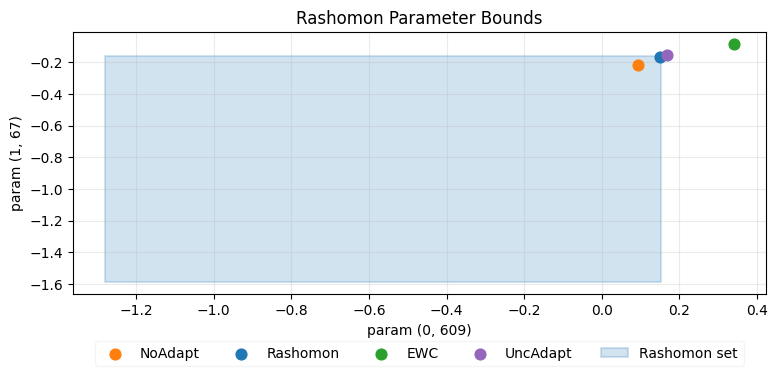

In [26]:
param_indices = [
    (0, 609), 
    # (0, 1527), 
    # (1, 169),
    (1, 67),
    # (0, 2077), 
]  # example: plot bounds for param tensors 0 and 1, and 2 and 3

scatter_points = [
    {
        'coordinates': (
            actor_parameters_dct['source'][param_indices[0][0]].detach().flatten()[param_indices[0][1]],
            actor_parameters_dct['source'][param_indices[1][0]].detach().flatten()[param_indices[1][1]],
            # actor_parameters_dct['source'][param_indices[2][0]].detach().flatten()[param_indices[2][1]],
        ),
        'label': 'NoAdapt',
        'color': 'tab:orange'
    },
    {
        'coordinates': (
            actor_parameters_dct['downstream_rashomon'][param_indices[0][0]].detach().flatten()[param_indices[0][1]],
            actor_parameters_dct['downstream_rashomon'][param_indices[1][0]].detach().flatten()[param_indices[1][1]],
            # actor_parameters_dct['downstream_rashomon'][param_indices[2][0]].detach().flatten()[param_indices[2][1]],
        ),
        'label': 'Rashomon',
        'color': 'tab:blue'
    },
    {
        'coordinates': (
            actor_parameters_dct['downstream_ewc'][param_indices[0][0]].detach().flatten()[param_indices[0][1]],
            actor_parameters_dct['downstream_ewc'][param_indices[1][0]].detach().flatten()[param_indices[1][1]],
            # actor_parameters_dct['downstream_ewc'][param_indices[2][0]].detach().flatten()[param_indices[2][1]],
        ),
        'label': 'EWC',
        'color': 'tab:green'
    },
    {
        'coordinates': (
            actor_parameters_dct['downstream_unconstrained'][param_indices[0][0]].detach().flatten()[param_indices[0][1]],
            actor_parameters_dct['downstream_unconstrained'][param_indices[1][0]].detach().flatten()[param_indices[1][1]],
            # actor_parameters_dct['downstream_unconstrained'][param_indices[2][0]].detach().flatten()[param_indices[2][1]],
        ),
        'label': 'UncAdapt',
        'color': 'tab:purple'
    }

]

plot_param_bounds(
    rashomon_bounds_lower,
    rashomon_bounds_upper,
    param_indices=param_indices,
    scatter_points=scatter_points,
    title="Rashomon Parameter Bounds",
    figsize=(8, 4),
    legend_loc='lower center',
    # legend_bbox_to_anchor=None,
    legend_bbox_to_anchor=(0.5, -0.3),
    legend_ncol=5
)

In [24]:
outside_indices_sorted_by_width_merged_df.head(5)

,tensor_idx,flat_idx,width_unconstrained,width_ewc
0,0,609,1.433758,1.433758
1,1,67,1.429165,1.429165
2,0,2077,1.386713,1.386713
3,0,1078,1.381765,1.381765
4,0,1077,1.380969,1.380969


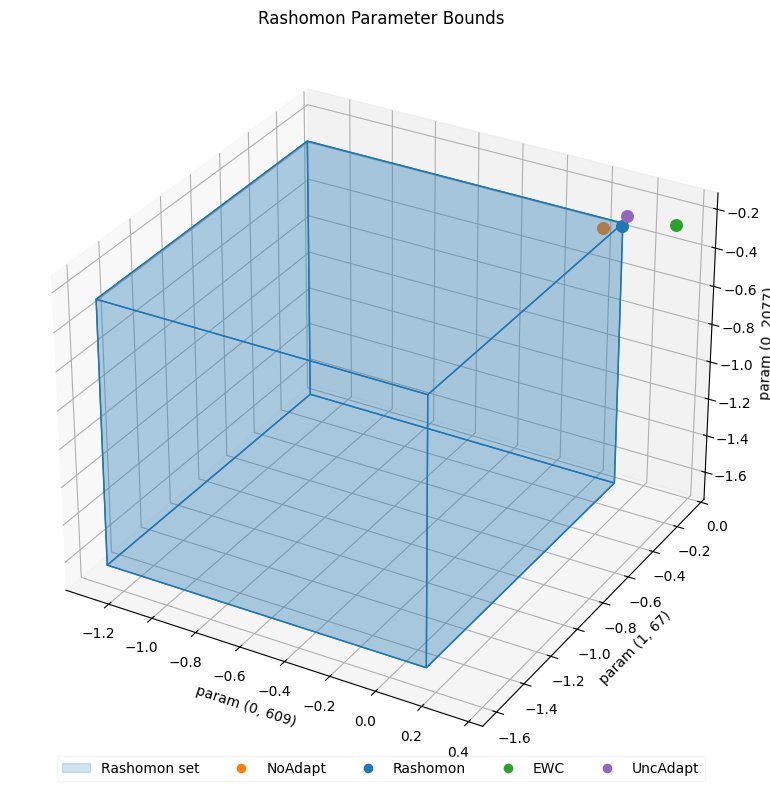

In [25]:
param_indices = [
    (0, 609), 
    # (0, 1527), 
    # (1, 169),
    (1, 67),
    (0, 2077), 
]  # example: plot bounds for param tensors 0 and 1, and 2 and 3

scatter_points = [
    {
        'coordinates': (
            actor_parameters_dct['source'][param_indices[0][0]].detach().flatten()[param_indices[0][1]],
            actor_parameters_dct['source'][param_indices[1][0]].detach().flatten()[param_indices[1][1]],
            actor_parameters_dct['source'][param_indices[2][0]].detach().flatten()[param_indices[2][1]],
        ),
        'label': 'NoAdapt',
        'color': 'tab:orange'
    },
    {
        'coordinates': (
            actor_parameters_dct['downstream_rashomon'][param_indices[0][0]].detach().flatten()[param_indices[0][1]],
            actor_parameters_dct['downstream_rashomon'][param_indices[1][0]].detach().flatten()[param_indices[1][1]],
            actor_parameters_dct['downstream_rashomon'][param_indices[2][0]].detach().flatten()[param_indices[2][1]],
        ),
        'label': 'Rashomon',
        'color': 'tab:blue'
    },
    {
        'coordinates': (
            actor_parameters_dct['downstream_ewc'][param_indices[0][0]].detach().flatten()[param_indices[0][1]],
            actor_parameters_dct['downstream_ewc'][param_indices[1][0]].detach().flatten()[param_indices[1][1]],
            actor_parameters_dct['downstream_ewc'][param_indices[2][0]].detach().flatten()[param_indices[2][1]],
        ),
        'label': 'EWC',
        'color': 'tab:green'
    },
    {
        'coordinates': (
            actor_parameters_dct['downstream_unconstrained'][param_indices[0][0]].detach().flatten()[param_indices[0][1]],
            actor_parameters_dct['downstream_unconstrained'][param_indices[1][0]].detach().flatten()[param_indices[1][1]],
            actor_parameters_dct['downstream_unconstrained'][param_indices[2][0]].detach().flatten()[param_indices[2][1]],
        ),
        'label': 'UncAdapt',
        'color': 'tab:purple'
    }

]

plot_param_bounds(
    rashomon_bounds_lower,
    rashomon_bounds_upper,
    param_indices=param_indices,
    scatter_points=scatter_points,
    title="Rashomon Parameter Bounds",
    figsize=(8, 8),
    legend_loc='lower center',
    # legend_bbox_to_anchor=None,
    legend_bbox_to_anchor=(0.5, -0.02),
    legend_ncol=5
)

## Expand the Rashomon set

### Check the distances between actor parameters

In [27]:
# Pairwise L2 distances between actors' full parameter vectors

def actor_param_vector(param_list):
    return torch.cat([p.detach().flatten().cpu() for p in param_list], dim=0)

actor_names = sorted(actor_parameters_dct.keys())
actor_vectors = {name: actor_param_vector(actor_parameters_dct[name]) for name in actor_names}

# Sanity check: all actors should have same total parameter count
sizes = {name: vec.numel() for name, vec in actor_vectors.items()}
if len(set(sizes.values())) != 1:
    raise ValueError(f"Actors have different parameter vector sizes: {sizes}")

actor_l2_distance_df = pandas.DataFrame(index=actor_names, columns=actor_names, dtype=float)

for name_i in actor_names:
    for name_j in actor_names:
        dist = torch.norm(actor_vectors[name_i] - actor_vectors[name_j], p=2).item()
        actor_l2_distance_df.loc[name_i, name_j] = dist

print("Pairwise L2 distance matrix:")
display(actor_l2_distance_df)

# Optional long-form table (unique pairs only)
actor_l2_distance_pairs_df = (
    actor_l2_distance_df.where(
        pandas.DataFrame(
            [[i < j for j in range(len(actor_names))] for i in range(len(actor_names))],
            index=actor_names,
            columns=actor_names,
        )
    )
    .stack()
    .reset_index()
)
actor_l2_distance_pairs_df.columns = ["actor_a", "actor_b", "l2_distance"]
actor_l2_distance_pairs_df = actor_l2_distance_pairs_df.sort_values("l2_distance", ascending=False).reset_index(drop=True)

print("\nTop actor pair distances:")
display(actor_l2_distance_pairs_df)

Pairwise L2 distance matrix:


,downstream_ewc,downstream_rashomon,downstream_unconstrained,source
downstream_ewc,0.000000,11.419453,13.212538,9.411122
downstream_rashomon,11.419453,0.000000,12.368153,9.971666
downstream_unconstrained,13.212538,12.368153,0.000000,9.817380
source,9.411122,9.971666,9.817380,0.000000



Top actor pair distances:


,actor_a,actor_b,l2_distance
0,downstream_ewc,downstream_unconstrained,13.212538
1,downstream_rashomon,downstream_unconstrained,12.368153
2,downstream_ewc,downstream_rashomon,11.419453
3,downstream_rashomon,source,9.971666
4,downstream_unconstrained,source,9.817380
5,downstream_ewc,source,9.411122


### Expansion

In [32]:
rashomon_bounded_model.param_l

[tensor([[ 0.0085, -0.1211,  0.0894,  ...,  0.2648,  0.2997, -1.1948],
         [-0.1651,  0.0188, -0.2835,  ..., -1.6138, -1.3070, -1.1587],
         [-0.2749,  0.1316, -0.1660,  ..., -0.2955,  0.1840, -1.0559],
         ...,
         [-0.2993, -0.0646, -0.0541,  ...,  0.0400, -0.1719, -1.1736],
         [-0.1875,  0.1038,  0.1160,  ...,  0.3963, -0.1194, -1.1921],
         [ 0.1057,  0.1360,  0.1162,  ...,  0.2890,  0.0694, -1.5214]],
        requires_grad=True),
 tensor([-0.0204,  0.0799,  0.2673, -1.6599,  0.3095,  0.3235,  0.1178,  0.1488,
          0.3142,  0.2589, -0.2191,  0.1698,  0.3144,  0.0645,  0.0556,  0.0531,
         -1.5633,  0.2203, -0.2720,  0.2778,  0.0824,  0.0684,  0.0126,  0.0312,
         -1.6803,  0.1392,  0.2610, -0.1326,  0.3120, -0.2186,  0.0539,  0.1997,
         -0.0558,  0.0046, -0.1820,  0.0336,  0.2542,  0.0068,  0.2928,  0.0244,
          0.0111, -0.2059,  0.2719,  0.1527,  0.2305, -0.0484,  0.0302,  0.2165,
          0.3341,  0.3152,  0.0995,  0.0506,

In [33]:
total_params_param_l = sum(t.numel() for t in rashomon_bounded_model.param_l)
print(f"Total number of parameters in rashomon_bounded_model.param_l: {total_params_param_l}")

Total number of parameters in rashomon_bounded_model.param_l: 69380


In [34]:
bernoulli_samples = torch.bernoulli(torch.full((total_params_param_l,), 0.5)).to(torch.int64)

print(f"Generated {bernoulli_samples.numel()} Bernoulli(0.5) samples")
print(bernoulli_samples[:20])

Generated 69380 Bernoulli(0.5) samples
tensor([1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0])


In [35]:
# Build one sampled parameter list from Rashomon bounds using bernoulli_samples:
# 0 -> take lower bound, 1 -> take upper bound

if bernoulli_samples.numel() != total_params_param_l:
    raise ValueError(
        f"Size mismatch: bernoulli_samples={bernoulli_samples.numel()} vs total_params_param_l={total_params_param_l}"
    )

sampled_param_list = []
offset = 0

for l_t, u_t in zip(rashomon_bounded_model.param_l, rashomon_bounded_model.param_u):
    n = l_t.numel()
    mask = bernoulli_samples[offset:offset + n].to(dtype=torch.bool, device=l_t.device).reshape(l_t.shape)
    sampled_t = torch.where(mask, u_t, l_t)  # True(1)->upper, False(0)->lower
    sampled_param_list.append(sampled_t)
    offset += n

print(f"Created sampled_param_list with {len(sampled_param_list)} tensors.")
print(f"Consumed Bernoulli samples: {offset}")

Created sampled_param_list with 6 tensors.
Consumed Bernoulli samples: 69380


In [36]:
sampled_param_list

[tensor([[ 0.1285,  0.0121,  0.0894,  ...,  0.2648,  0.2997,  1.5558],
         [-0.1651,  0.0188, -0.2835,  ..., -0.1436,  0.1627,  1.5919],
         [-0.2749,  0.1316, -0.1660,  ..., -0.2955,  0.1840, -1.0559],
         ...,
         [-0.2993, -0.0646, -0.0541,  ...,  0.0400, -0.1719, -1.1736],
         [-0.1875,  0.1038,  0.1160,  ...,  0.3963, -0.1194, -1.1921],
         [ 0.1057,  0.1360,  0.1162,  ...,  0.2890,  0.0694,  1.2292]],
        grad_fn=<WhereBackward0>),
 tensor([-0.0204,  0.0799,  0.2673, -0.2694,  0.3095,  0.3235,  0.1178,  0.1488,
          0.3142,  0.2589, -0.2191,  0.1698,  0.3144,  0.0645,  0.0556,  0.0531,
         -1.5633,  0.2203, -0.2720,  0.2778,  0.0824,  0.0684,  0.0126,  0.0312,
         -0.2643,  0.1392,  0.2610, -0.1326,  0.3120, -0.2186,  0.0539,  0.1997,
         -0.0558,  0.0046, -0.1820,  0.0336,  0.2542,  0.0068,  0.2928,  0.0244,
          0.0111, -0.2059,  0.2719,  0.1527,  0.2305, -0.0484,  0.0302,  0.2165,
          0.3341,  0.3152,  0.0995,  0

In [37]:
# Initialize a new policy network from sampled_param_list

template_state_dict = actors["source"]["actor"].state_dict()
state_keys = list(template_state_dict.keys())

if len(sampled_param_list) != len(state_keys):
    raise ValueError(
        f"Length mismatch: sampled_param_list={len(sampled_param_list)} vs state_dict keys={len(state_keys)}"
    )

sampled_state_dict = {}
for k, sampled_t in zip(state_keys, sampled_param_list):
    if tuple(sampled_t.shape) != tuple(template_state_dict[k].shape):
        raise ValueError(
            f"Shape mismatch for '{k}': sampled={tuple(sampled_t.shape)} vs expected={tuple(template_state_dict[k].shape)}"
        )
    sampled_state_dict[k] = sampled_t.detach().clone().to(template_state_dict[k].device)

new_rashomon_reference_policy = _build_actor_from_state_dict(sampled_state_dict).to(DEVICE)
new_rashomon_reference_policy.eval()

print("Initialized policy network from sampled_param_list.")
print(new_rashomon_reference_policy)

Initialized policy network from sampled_param_list.
Sequential(
  (0): Linear(in_features=9, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=256, bias=True)
  (3): ReLU()
  (4): Linear(in_features=256, out_features=4, bias=True)
)


In [38]:
from src.trainer.IntervalTrainer import IntervalTrainer

In [44]:
directory = resolve_policy_dir(outputs_root=OUTPUTS_ROOT, train_task_setting=TASK_SETTING, train_seed=0, policy_subdir=RASHOMON_RUN_SUBDIR)

In [46]:
rashomon_dataset_path = directory / "rashomon_dataset.pt"
rashomon_dataset = torch_load_any(rashomon_dataset_path)

print(f"Loaded Rashomon dataset from: {rashomon_dataset_path}")
print(f"Type: {type(rashomon_dataset)}")

Loaded Rashomon dataset from: /vol/bitbucket/ma5923/_projects/CertifiedContinualLearning/projects/safe_crl/pipelines/trajectory_retention/lunarlander/outputs/deterministic_vehicle_underpowered/seed_0/downstream_rashomon/rashomon_dataset.pt
Type: <class 'torch.utils.data.dataset.TensorDataset'>


In [51]:
interval_trainer = IntervalTrainer(
    model=new_rashomon_reference_policy,
    min_acc_limit=0.5,
    seed=0,
    n_iters=1_000,  # type: ignore[arg-type]
    min_acc_increment=0,
    T=100,
    checkpoint=100,  # type: ignore[arg-type]
)
interval_trainer.compute_rashomon_set(
    dataset=rashomon_dataset,
    multi_label=True,
    aggregation='min',  # type: ignore[arg-type]
)

Initial acc constraint violation: -0.0548 (Positive = violated)
Number of model parameters: 69380
Computing Rashomon set with limits: min_soft_acc_limit=0.50, min_hard_acc_limit=0.50
Initial bbox:  Obj=0.00,  Size=0.00,  Min acc hard=1.00,  Min acc soft=0.55


100%|██████████| 1000/1000 [00:32<00:00, 30.54it/s, size=1802.34, obj=0.026, min_soft_acc=0.502]


Final bbox:  Obj=0.03,  Size=1802.34,  Min acc hard=1.00,  Min acc soft=0.50
Computing final certificates over 256 samples
Num cert samples: 256
Checkpointed every 100 iterations for a total of 10 checkpoints
Checkpoints sizes: ['143.73', '339.69', '531.02', '722.55', '913.94', '1105.39', '1291.48', '1461.15', '1633.08', '1802.34']
Checkpoint certificates: ['1.00', '1.00', '1.00', '0.00', '1.00', '1.00', '0.00', '1.00', '1.00', '1.00']
Multitask certificates: []
----------------------- Finished Computing Rashomon set ------------------------


In [52]:
def _certificate_to_float(certificate: object) -> float:
    if certificate is None:
        return float("-inf")
    if isinstance(certificate, list):
        vals = [float(v) for v in certificate if v is not None]
        return min(vals) if vals else float("-inf")
    return float(certificate)  # type: ignore[arg-type]

min_hard_spec = 1.0

cert_values = [_certificate_to_float(cert) for cert in interval_trainer.certificates]
valid_indices = [i for i, cert in enumerate(cert_values) if cert >= min_hard_spec]
if not valid_indices:
    best_cert = max(cert_values) if cert_values else float("-inf")
    raise ValueError(
        f"No Rashomon certificate satisfied min_hard_spec={min_hard_spec:.3f}. "
        f"Best certificate={best_cert:.6f}",
    )

selected_idx = valid_indices[-1]
bounded_model = interval_trainer.bounds[selected_idx]
param_bounds_l = [p.detach().cpu() for p in bounded_model.param_l]
param_bounds_u = [p.detach().cpu() for p in bounded_model.param_u]